# Data cleaning and preprocessing

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

STATE = 42

In [2]:
hurricanes = pd.read_csv("data/hurricane_data.csv") # renamed kaggle csv from storms to hurricane_data

## Check df info

In [3]:
hurricanes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22705 entries, 0 to 22704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          22705 non-null  object 
 1   year                          22705 non-null  int64  
 2   month                         22705 non-null  int64  
 3   day                           22705 non-null  int64  
 4   hour                          22705 non-null  int64  
 5   lat                           22705 non-null  float64
 6   long                          22705 non-null  float64
 7   status                        22705 non-null  object 
 8   category                      5162 non-null   float64
 9   wind                          22705 non-null  int64  
 10  pressure                      22705 non-null  int64  
 11  tropicalstorm_force_diameter  22705 non-null  int64  
 12  hurricane_force_diameter      22705 non-null  int64  
dtypes

We can see that the only column that contains missing values is `category`, which makes sense because the storms in the dataset that are not hurricanes would not have a category.
<br>
<br>
To cross reference, rows that contain the 'hurricane' status will be checked if they contain any missing values from the category columns.

In [4]:
# Extract rows that have a status of "hurricane"
status_hurricane = hurricanes[hurricanes['status'] == 'hurricane'].copy()
print("Difference between all rows of status \"hurricane\" and rows that contain missing values: ", len(status_hurricane) - len(status_hurricane.dropna()))

Difference between all rows of status "hurricane" and rows that contain missing values:  0


We've now accounted for all of the missing values that exist and will be moving forward with the 5162 rows that have the "hurricane" status.

## Check for duplicate values

In [5]:
status_hurricane.duplicated()

70       False
71       False
72       False
73       False
74       False
         ...  
22674    False
22675    False
22676    False
22677    False
22678    False
Length: 5162, dtype: bool

We can see that there are no duplicate values after running the `duplicated` function.

## Account for placeholder data

In the plots below, we see a substantial number of rows in the dataset that have -999 for pressure and -1999 for tropical storm/ hurricane diameter; these are sentinel values to act as placeholders for unrecorded data. We could account for these rows by creating a new `decade` column and imputing the median pressure/diameter for that decade- but, by using the median of a decade, it would be effectively "flattening" the variation within that 10-year block. Example: if there are 500 storms in a decade, and 50 of them are missing pressure data, those 50 storms would be assigned the exact same value.

<Axes: xlabel='pressure', ylabel='Count'>

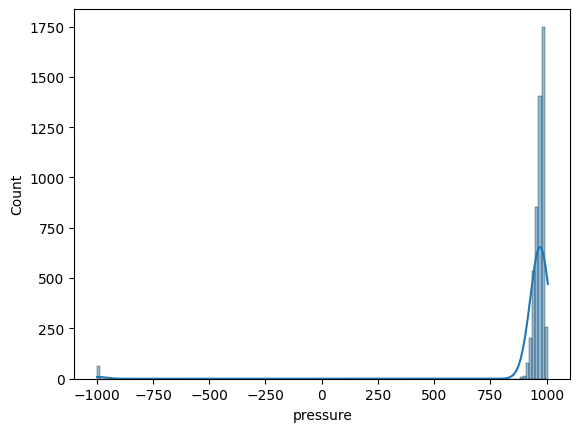

In [6]:
sns.histplot(data=status_hurricane, x='pressure', kde=True)

<Axes: xlabel='tropicalstorm_force_diameter', ylabel='Count'>

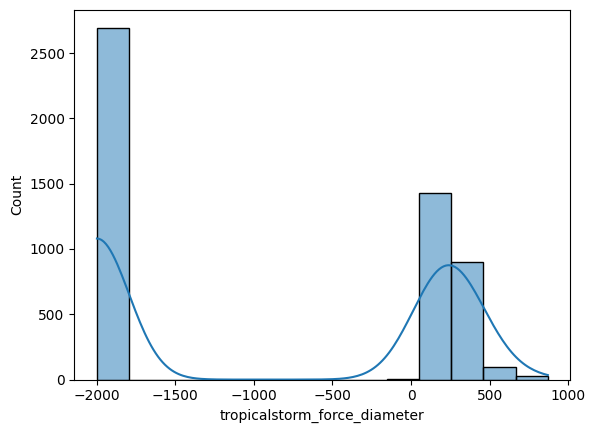

In [7]:
sns.histplot(data=status_hurricane, x='tropicalstorm_force_diameter', kde=True)

<Axes: xlabel='hurricane_force_diameter', ylabel='Count'>

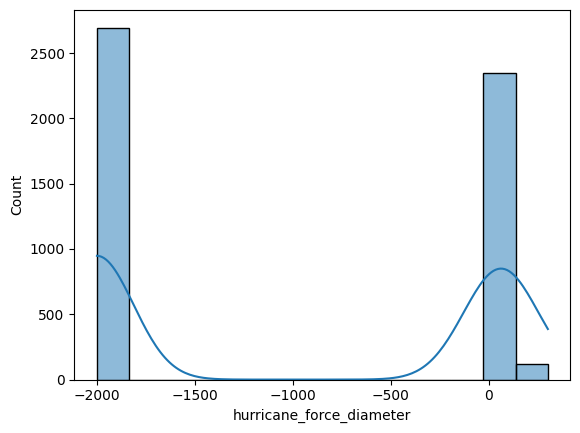

In [8]:
sns.histplot(data=status_hurricane, x='hurricane_force_diameter', kde=True)

As an alternative, a Random forest regressor will be used to perform Model-based imputation.

In [9]:
# replace placeholders with NANs
status_hurricane['pressure'] = status_hurricane['pressure'].replace(-999, np.nan)
status_hurricane['tropicalstorm_force_diameter'] = status_hurricane['tropicalstorm_force_diameter'].replace(-1998, np.nan)
status_hurricane['hurricane_force_diameter'] = status_hurricane['hurricane_force_diameter'].replace(-1998, np.nan)

# Columns safe for imputation
impute_cols = ['year', 'month', 'day', 'hour', 'lat', 'long', 'wind', 'tropicalstorm_force_diameter', 'hurricane_force_diameter']

# Create a copy to keep your original data intact
data_for_impute = status_hurricane[impute_cols].copy()

In [10]:
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, n_jobs=-1),
    max_iter=20,     # Maximum number of imputation rounds
    tol=1e-3,        # Stopping criterion: change between iterations
    random_state=STATE
)
df_imputed = imputer.fit_transform(data_for_impute)

# Replace the old columns with the cleaned ones
status_hurricane[impute_cols] = df_imputed

/home/viviteto/miniforge3/envs/ml_env/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## Check integrity of df after model-based imputation

In [11]:
print(status_hurricane.isnull().sum())

name                             0
year                             0
month                            0
day                              0
hour                             0
lat                              0
long                             0
status                           0
category                         0
wind                             0
pressure                        62
tropicalstorm_force_diameter     0
hurricane_force_diameter         0
dtype: int64


The number of rows that still have missing NaN's after imputation is close to 1% of the 5162 rows; they will be dropped. 

In [12]:
status_hurricane = status_hurricane.dropna()

Integer values were casted as floats during the imputation process, they will be returned back to ints.

In [13]:
status_hurricane['year'] = status_hurricane['year'].round().astype(int)
status_hurricane['month'] = status_hurricane['month'].round().astype(int)
status_hurricane['day'] = status_hurricane['day'].round().astype(int)
status_hurricane['hour'] = status_hurricane['hour'].round().astype(int)
status_hurricane['wind'] = status_hurricane['wind'].round().astype(int)

status_hurricane['pressure'] = status_hurricane['pressure'].round().astype(int)
status_hurricane['tropicalstorm_force_diameter'] = status_hurricane['tropicalstorm_force_diameter'].round().astype(int)
status_hurricane['hurricane_force_diameter'] = status_hurricane['hurricane_force_diameter'].round().astype(int)

<Axes: xlabel='pressure', ylabel='Count'>

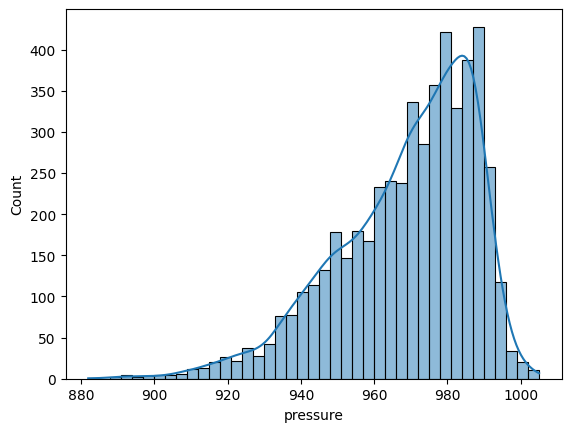

In [14]:
sns.histplot(data=status_hurricane, x='pressure', kde=True)

<Axes: xlabel='tropicalstorm_force_diameter', ylabel='Count'>

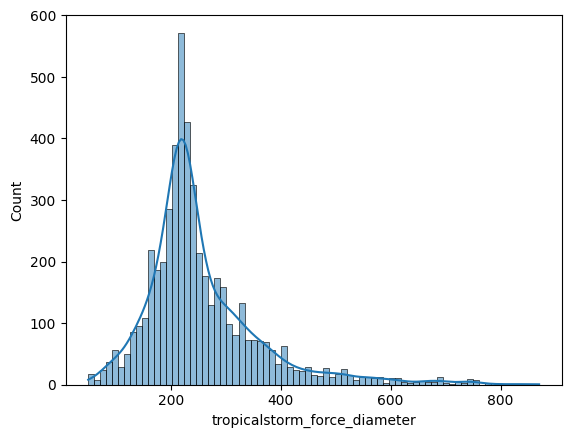

In [15]:
sns.histplot(data=status_hurricane, x='tropicalstorm_force_diameter', kde=True)

<Axes: xlabel='hurricane_force_diameter', ylabel='Count'>

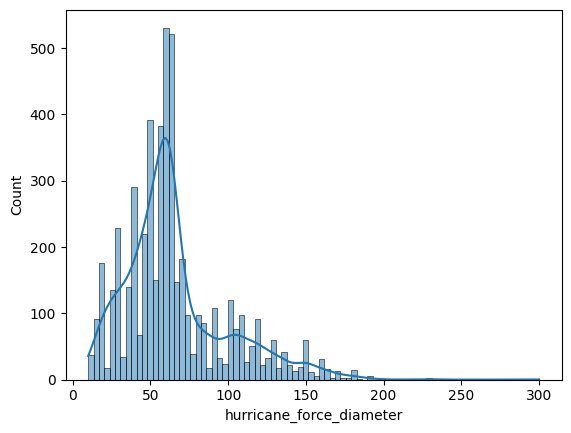

In [16]:
sns.histplot(data=status_hurricane, x='hurricane_force_diameter', kde=True)

## Create binary Non/Major target variable

In [17]:
status_hurricane['hurricane_class'] = 0
status_hurricane.loc[status_hurricane['category'] > 2.0, 'hurricane_class'] = 1

status_hurricane.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5100 entries, 70 to 22678
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          5100 non-null   object 
 1   year                          5100 non-null   int64  
 2   month                         5100 non-null   int64  
 3   day                           5100 non-null   int64  
 4   hour                          5100 non-null   int64  
 5   lat                           5100 non-null   float64
 6   long                          5100 non-null   float64
 7   status                        5100 non-null   object 
 8   category                      5100 non-null   float64
 9   wind                          5100 non-null   int64  
 10  pressure                      5100 non-null   int64  
 11  tropicalstorm_force_diameter  5100 non-null   int64  
 12  hurricane_force_diameter      5100 non-null   int64  
 13  hurric

In [18]:
# write df to csv
status_hurricane.to_csv('data/cleaned_data.csv', index=False)

In [19]:
# split into training and testing
train_df, test_df = train_test_split(status_hurricane, test_size=0.2, random_state=STATE)

train_df.to_csv('data/train.csv', index=False)
test_df.to_csv('data/test.csv', index=False)